In [285]:
import warnings
warnings.filterwarnings("ignore")
# ============================================================================
# SECTION 1 : IMPORT DES BIBLIOTHÈQUES
# ============================================================================

# Manipulation des données
import os
import json
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

# Dates
from datetime import datetime, timedelta

# Métriques d'évaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prétraitement
from sklearn.preprocessing import StandardScaler

# Modélisation
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Séries temporelles
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

In [286]:
# ============================================================================
# SECTION 2 : CHARGEMENT ET EXPLORATION INITIALE
# ============================================================================

In [287]:
# Chargement du CSV avec encodage latin1 (gère les caractères spéciaux)
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

In [288]:
# Aperçu des 5 premières lignes (vérifier structure et colonnes)
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [289]:

# Infos générales : types, valeurs non-nulles, mémoire
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [290]:
# Statistiques descriptives des colonnes numériques (min, max, moyenne, quartiles)
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [291]:
# ============================================================================
# SECTION 3 : AGRÉGATION TEMPORELLE
# ============================================================================

# Conversion de la colonne date en format datetime (indispensable pour manipuler le temps)
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Agrégation : regroupement par jour et somme des ventes
# Un jour peut avoir plusieurs transactions -> on les somme
df_journalier = df.groupby('Order Date')['Sales'].sum().reset_index()

# Renommage des colonnes pour plus de clarté
df_journalier.columns = ['date', 'ventes']

# Vérification de la période couverte et du nombre de jours
print(f"Période: {df_journalier['date'].min()} à {df_journalier['date'].max()}")
print(f"Nombre de jours: {len(df_journalier)}")

Période: 2014-01-03 00:00:00 à 2017-12-30 00:00:00
Nombre de jours: 1237


In [292]:
# ============================================================================
# SECTION 4 : VÉRIFICATION DE LA COUVERTURE ANNUELLE
# ============================================================================

# Compte du nombre de jours par année
# Utile pour vérifier qu'on a assez de données pour capturer la saisonnalité
print(df_journalier['date'].dt.year.value_counts().sort_index())

date
2014    305
2015    290
2016    320
2017    322
Name: count, dtype: int64


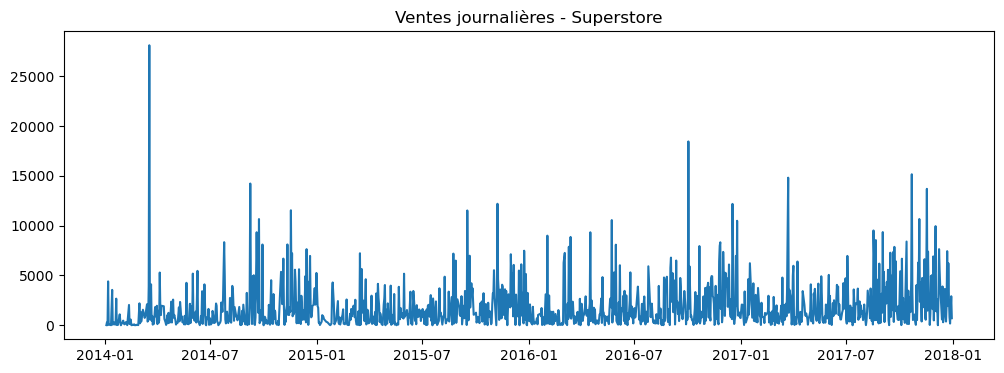

In [293]:
# ============================================================================
# SECTION 5 : VISUALISATION DE LA SÉRIE TEMPORELLE
# ============================================================================

# Création d'une figure avec une taille adaptée (12 pouces de large, 4 de haut)
plt.figure(figsize=(12, 4))

# Tracé de la série temporelle : date en X, ventes en Y
plt.plot(df_journalier['date'], df_journalier['ventes'])

# Titre du graphique
plt.title('Ventes journalières - Superstore')

# Affichage
plt.show()

In [294]:
# ============================================================================
# SECTION 6 : CRÉATION D'UNE COPIE DE TRAVAIL
# ============================================================================

# Copie explicite du DataFrame pour éviter les modifications accidentelles sur l'original
# Indispensable pour préserver les données brutes
df = df.copy()

In [295]:
# ============================================================================
# SECTION 7 : STATISTIQUES DESCRIPTIVES DES VENTES
# ============================================================================

# Résumé statistique des ventes journalières :
# - count : nombre de jours
# - mean  : moyenne des ventes
# - std   : écart-type (volatilité)
# - min   : vente minimale
# - 25%/50%/75% : quartiles
# - max   : vente maximale (pic)
df_journalier['ventes'].describe()

count     1237.000000
mean      1857.074261
std       2305.538776
min          2.025000
25%        377.736000
50%       1063.185000
75%       2395.786000
max      28106.716000
Name: ventes, dtype: float64

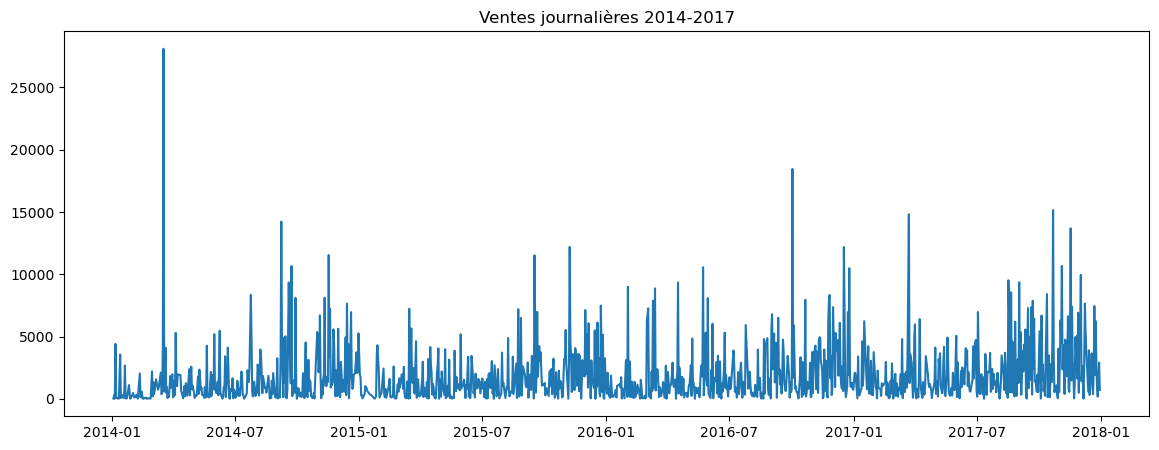

In [296]:
# ============================================================================
# SECTION 8 : VISUALISATION COMPLÈTE (2014-2017)
# ============================================================================

# Figure plus large (14 pouces) pour mieux voir la tendance sur 4 ans
plt.figure(figsize=(14, 5))

# Tracé de la série complète
plt.plot(df_journalier['date'], df_journalier['ventes'])

# Titre explicite avec la période
plt.title('Ventes journalières 2014-2017')

plt.show()

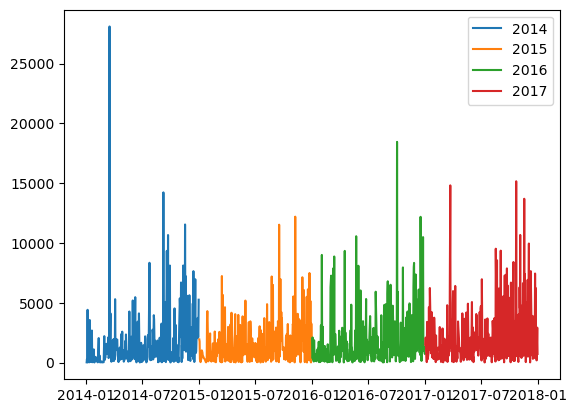

In [297]:
# ============================================================================
# SECTION 9 : COMPARAISON VISUELLE ENTRE ANNÉES
# ============================================================================

# Boucle sur chaque année pour superposer les courbes
# Permet de visualiser l'évolution annuelle et détecter des patterns récurrents
for year in [2014, 2015, 2016, 2017]:
    data = df_journalier[df_journalier['date'].dt.year == year]
    plt.plot(data['date'], data['ventes'], label=str(year))

# Ajout de la légende pour identifier chaque année
plt.legend()

plt.show()

In [298]:
# ============================================================================
# SECTION 10 : SAISONNALITÉ MENSUELLE
# ============================================================================

# Extraction du numéro du mois (1 à 12) à partir de la date
df_journalier['mois'] = df_journalier['date'].dt.month

# Calcul de la moyenne des ventes pour chaque mois (toutes années confondues)
# Permet d'identifier les mois les plus forts (Noël, Black Friday) et les creux
moy_par_mois = df_journalier.groupby('mois')['ventes'].mean()

print(moy_par_mois)

mois
1     1130.057567
2      737.669770
3     1934.014045
4     1350.609104
5     1396.655961
6     1527.186793
7     1443.510755
8     1574.693693
9     2822.476566
10    1821.118043
11    3038.457509
12    2828.639161
Name: ventes, dtype: float64


In [299]:
# ============================================================================
# SECTION 11 : DÉTECTION DES OUTLIERS (MÉTHODE IQR)
# ============================================================================

# Calcul du premier quartile (25% des données en dessous)
Q1 = df_journalier['ventes'].quantile(0.25)

# Calcul du troisième quartile (75% des données en dessous)
Q3 = df_journalier['ventes'].quantile(0.75)

# Écart interquartile (mesure de dispersion)
IQR = Q3 - Q1

# Borne supérieure : au-delà = outlier
# Multiplicateur 1.5 = règle standard de Tukey
borne_sup = Q3 + 1.5 * IQR

# Filtrage des outliers (ventes anormalement élevées)
outliers = df_journalier[df_journalier['ventes'] > borne_sup]

print(f"Outliers détectés: {len(outliers)}")

Outliers détectés: 84


In [300]:
# ============================================================================
# SECTION 12 : STRUCTURE DU DATASET
# ============================================================================

# Affichage des dimensions du DataFrame original (avant agrégation)
print("=== STRUCTURE DU DATASET ===")

# Nombre de lignes (transactions) avec séparateur de milliers
print(f"Lignes: {df.shape[0]:,}")

# Nombre de colonnes (variables)
print(f"Colonnes: {df.shape[1]}")

# Liste complète des noms de colonnes
print(f"\nColonnes: {df.columns.tolist()}")

=== STRUCTURE DU DATASET ===
Lignes: 9,994
Colonnes: 21

Colonnes: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [301]:
# ============================================================================
# SECTION 13 : APERÇU DES DONNÉES
# ============================================================================

# Affichage des 10 premières lignes pour vérifier la structure
print("\n=== APERÇU DES DONNÉES ===")
df.head(10)

# Affichage des 10 dernières lignes pour voir la fin du dataset
print("\n=== FIN DES DONNÉES ===")
df.tail(10)


=== APERÇU DES DONNÉES ===

=== FIN DES DONNÉES ===


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9984,9985,CA-2015-100251,2015-05-17,5/23/2015,Standard Class,DV-13465,Dianna Vittorini,Consumer,United States,Long Beach,...,11561,East,OFF-LA-10003766,Office Supplies,Labels,Self-Adhesive Removable Labels,31.500,10,0.0,15.1200
9985,9986,CA-2015-100251,2015-05-17,5/23/2015,Standard Class,DV-13465,Dianna Vittorini,Consumer,United States,Long Beach,...,11561,East,OFF-SU-10000898,Office Supplies,Supplies,Acme Hot Forged Carbon Steel Scissors with Nic...,55.600,4,0.0,16.1240
9986,9987,CA-2016-125794,2016-09-29,10/3/2016,Standard Class,ML-17410,Maris LaWare,Consumer,United States,Los Angeles,...,90008,West,TEC-AC-10003399,Technology,Accessories,Memorex Mini Travel Drive 64 GB USB 2.0 Flash ...,36.240,1,0.0,15.2208
9987,9988,CA-2017-163629,2017-11-17,11/21/2017,Standard Class,RA-19885,Ruben Ausman,Corporate,United States,Athens,...,30605,South,TEC-AC-10001539,Technology,Accessories,Logitech G430 Surround Sound Gaming Headset wi...,79.990,1,0.0,28.7964
9988,9989,CA-2017-163629,2017-11-17,11/21/2017,Standard Class,RA-19885,Ruben Ausman,Corporate,United States,Athens,...,30605,South,TEC-PH-10004006,Technology,Phones,Panasonic KX - TS880B Telephone,206.100,5,0.0,55.6470
9989,9990,CA-2014-110422,2014-01-21,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,2017-05-04,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [302]:
# ============================================================================
# SECTION 14 : VÉRIFICATION DES TYPES ET VALEURS MANQUANTES
# ============================================================================

print("\n=== TYPES ET VALEURS MANQUANTES ===")

# Affichage du type de chaque colonne (int, float, object, datetime)
print(df.dtypes)

# Comptage des NaN par colonne (0 = propre)
print("\nValeurs manquantes par colonne:")
print(df.isnull().sum())

# Total des valeurs manquantes dans tout le DataFrame
print(f"\nTotal valeurs manquantes: {df.isnull().sum().sum()}")


=== TYPES ET VALEURS MANQUANTES ===
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date                object
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

Valeurs manquantes par colonne:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region          

In [303]:
# ============================================================================
# SECTION 15 : DÉTECTION DES DOUBLONS
# ============================================================================

print("\n=== DOUBLONS ===")

# Doublons sur l'ensemble des colonnes (lignes identiques)
print(f"Doublons complets: {df.duplicated().sum()}")

# Doublons spécifiques : une même commande (Order ID) avec le même produit (Product ID)
# Cela indique des lignes potentiellement dupliquées par erreur
print(f"Doublons sur (Order ID, Product ID): {df.duplicated(subset=['Order ID', 'Product ID']).sum()}")


=== DOUBLONS ===
Doublons complets: 0
Doublons sur (Order ID, Product ID): 8


In [304]:
# ============================================================================
# SECTION 16 : STATISTIQUES DESCRIPTIVES GLOBALES
# ============================================================================

print("\n=== STATISTIQUES DESCRIPTIVES ===")

# Résumé statistique des colonnes numériques :
# - count : nombre d'observations
# - mean  : moyenne
# - std   : écart-type
# - min   : minimum
# - 25%/50%/75% : quartiles
# - max   : maximum
df.describe()


=== STATISTIQUES DESCRIPTIVES ===


,Row ID,Order Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [305]:
# ============================================================================
# SECTION 17 : STATISTIQUES DES VARIABLES CATÉGORIELLES
# ============================================================================

print("\n=== STATISTIQUES VARIABLES CATEGORIELLES ===")

# Résumé des colonnes de type texte (object) :
# - count : nombre de valeurs non-nulles
# - unique : nombre de valeurs distinctes
# - top : valeur la plus fréquente
# - freq : fréquence de la valeur la plus fréquente
df.describe(include=['object'])


=== STATISTIQUES VARIABLES CATEGORIELLES ===


,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2017-100111,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


In [306]:
# 1. Nettoyage
df_clean = df.drop_duplicates(subset=['Order ID', 'Product ID'])
print(f"Lignes après suppression doublons: {len(df_clean)}")

# 2. Ventes par segment
print("\n=== VENTES PAR SEGMENT ===")
print(df_clean.groupby('Segment')['Sales'].sum().sort_values(ascending=False))

# 3. Ventes par catégorie
print("\n=== VENTES PAR CATEGORIE ===")
print(df_clean.groupby('Category')['Sales'].sum().sort_values(ascending=False))

# 4. Série temporelle agrégée
df_journalier = df_clean.groupby('Order Date')['Sales'].sum().reset_index()
print(f"\nPériode: {df_journalier['Order Date'].min()} à {df_journalier['Order Date'].max()}")
print(f"Nombre de jours: {len(df_journalier)}")

Lignes après suppression doublons: 9986

=== VENTES PAR SEGMENT ===
Segment
Consumer       1.161013e+06
Corporate      7.056020e+05
Home Office    4.288950e+05
Name: Sales, dtype: float64

=== VENTES PAR CATEGORIE ===
Category
Technology         835759.7370
Furniture          741432.0433
Office Supplies    718317.7920
Name: Sales, dtype: float64

Période: 2014-01-03 00:00:00 à 2017-12-30 00:00:00
Nombre de jours: 1237


In [307]:
# Créer la série temporelle agrégée
df_journalier = df_clean.groupby('Order Date')['Sales'].sum().reset_index()
df_journalier.columns = ['date', 'ventes']

# Vérifier la régularité
jours_manquants = pd.date_range(df_journalier['date'].min(), df_journalier['date'].max()).difference(df_journalier['date'])
print(f"Jours sans vente: {len(jours_manquants)}")

Jours sans vente: 221


In [308]:
# ============================================================================
# SECTION 18 : ANALYSE DES JOURS SANS VENTES
# ============================================================================

# Date de début et fin de la période
date_min = df_journalier['date'].min()
date_max = df_journalier['date'].max()

# Nombre total de jours dans l'intervalle (+1 car inclusif)
total_jours = (date_max - date_min).days + 1

# Affichage des statistiques de couverture temporelle
print(f"Période: {date_min.date()} à {date_max.date()}")
print(f"Total jours dans la période: {total_jours}")
print(f"Jours avec ventes dans df_journalier: {len(df_journalier)}")
print(f"Jours sans ventes: {total_jours - len(df_journalier)}")

Période: 2014-01-03 à 2017-12-30
Total jours dans la période: 1458
Jours avec ventes dans df_journalier: 1237
Jours sans ventes: 221


In [309]:
# ============================================================================
# SECTION 19 : FEATURE ENGINEERING (VARIABLES TEMPORELLES)
# ============================================================================

# Copie du DataFrame journalier (déjà sans jours à zéro)
df_ventes = df_journalier.copy()

# Extraction du jour de la semaine (0 = lundi, 6 = dimanche)
df_ventes['jour_semaine'] = df_ventes['date'].dt.dayofweek

# Extraction du mois (1 à 12)
df_ventes['mois'] = df_ventes['date'].dt.month

# Extraction de l'année
df_ventes['annee'] = df_ventes['date'].dt.year

# Aperçu des nouvelles colonnes ajoutées
df_ventes.head()

,date,ventes,jour_semaine,mois,annee
0,2014-01-03,16.448,4,1,2014
1,2014-01-04,288.060,5,1,2014
2,2014-01-05,19.536,6,1,2014
3,2014-01-06,4407.100,0,1,2014
4,2014-01-07,87.158,1,1,2014


In [310]:
# ============================================================================
# SECTION 20 : RÉPARTITION DES VENTES PAR JOUR DE SEMAINE
# ============================================================================

# Extraction du jour de semaine depuis la date de commande
# Utile pour vérifier si certains jours n'ont jamais de ventes
df_clean['jour_semaine'] = pd.to_datetime(df_clean['Order Date']).dt.dayofweek

# Comptage du nombre de transactions par jour de semaine
jours_avec_ventes = df_clean['jour_semaine'].value_counts().sort_index()

print("Ventes par jour de semaine (0=lundi, 6=dimanche):")
print(jours_avec_ventes)

Ventes par jour de semaine (0=lundi, 6=dimanche):
jour_semaine
0    1871
1    1105
2     370
3    1461
4    1815
5    1655
6    1709
Name: count, dtype: int64


In [311]:
# ============================================================================
# SECTION 21 : CRÉATION D'UNE SÉRIE TEMPORELLE CONTINUE
# ============================================================================

# Reindexation pour avoir TOUS les jours (pas seulement ceux avec ventes)
# asfreq('D') : crée une fréquence journalière
# fill_value=0 : les jours sans ventes reçoivent la valeur 0
df_complet = df_journalier.set_index('date').asfreq('D', fill_value=0).reset_index()

# Renommage des colonnes
df_complet.columns = ['date', 'ventes']

# Vérification : nombre de jours où il n'y a eu aucune vente
print(f"Jours avec ventes = 0: {(df_complet['ventes'] == 0).sum()}")
print(df_complet.head(10))

Jours avec ventes = 0: 221
        date    ventes
0 2014-01-03    16.448
1 2014-01-04   288.060
2 2014-01-05    19.536
3 2014-01-06  4407.100
4 2014-01-07    87.158
5 2014-01-08     0.000
6 2014-01-09    40.544
7 2014-01-10    54.830
8 2014-01-11     9.940
9 2014-01-12     0.000


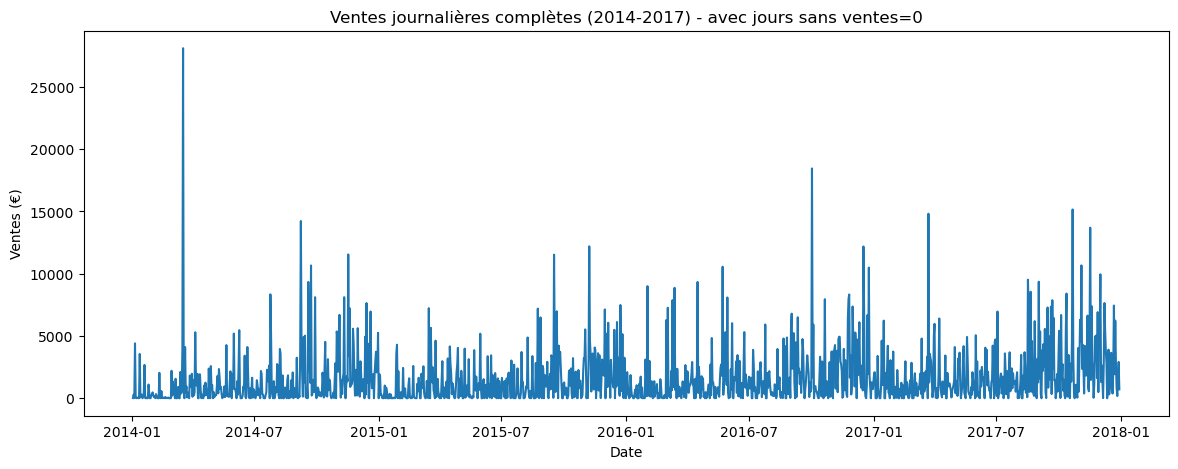

In [312]:
# ============================================================================
# SECTION 22 : VISUALISATION DE LA SÉRIE COMPLÈTE (AVEC LES 0)
# ============================================================================

# Figure de taille 14x5 pouces pour une bonne lisibilité
plt.figure(figsize=(14, 5))

# Tracé de la série continue (les jours sans ventes apparaissent à 0)
plt.plot(df_complet['date'], df_complet['ventes'])

# Titre indiquant que les jours sans ventes sont à 0
plt.title('Ventes journalières complètes (2014-2017) - avec jours sans ventes=0')
plt.xlabel('Date')
plt.ylabel('Ventes (€)')

plt.show()

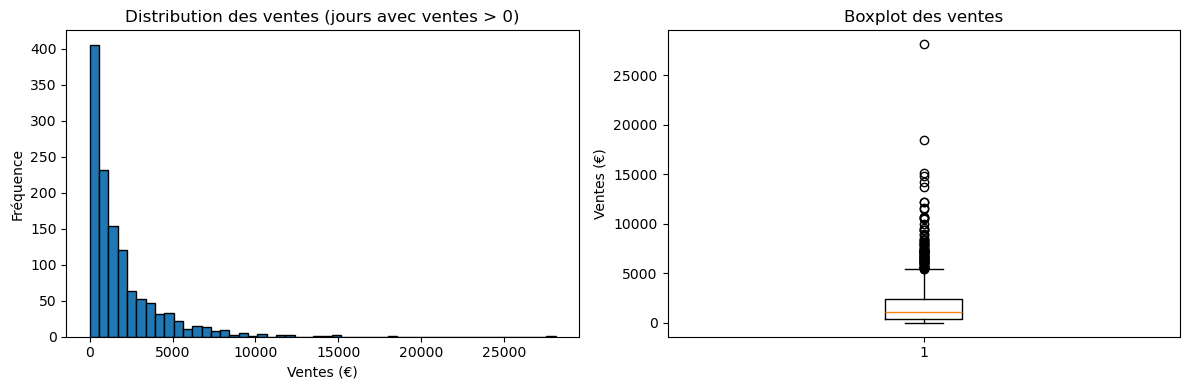

In [313]:
# ============================================================================
# SECTION 23 : DISTRIBUTION ET BOXPLOT DES VENTES
# ============================================================================

# Figure avec 2 graphiques côte à côte (1 ligne, 2 colonnes)
plt.figure(figsize=(12, 4))

# Graphique 1 : Histogramme (distribution)
plt.subplot(1, 2, 1)
# On filtre les ventes > 0 pour ne pas fausser avec les 0
plt.hist(df_complet[df_complet['ventes'] > 0]['ventes'], bins=50, edgecolor='black')
plt.title('Distribution des ventes (jours avec ventes > 0)')
plt.xlabel('Ventes (€)')
plt.ylabel('Fréquence')

# Graphique 2 : Boxplot (médiane, quartiles, outliers)
plt.subplot(1, 2, 2)
plt.boxplot(df_complet[df_complet['ventes'] > 0]['ventes'])
plt.title('Boxplot des ventes')
plt.ylabel('Ventes (€)')

# Ajustement automatique des espacements
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

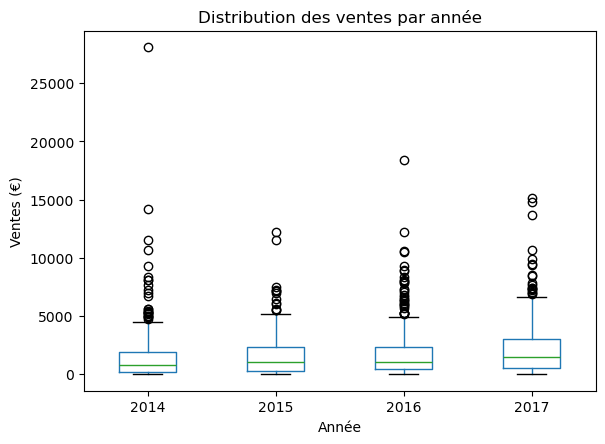

In [314]:
# ============================================================================
# SECTION 24 : BOXPLOT DES VENTES PAR ANNÉE
# ============================================================================

plt.figure(figsize=(12, 5))

# Extraction de l'année depuis la date
df_complet['annee'] = df_complet['date'].dt.year

# Boxplot groupé par année (uniquement jours avec ventes > 0)
# by='annee' : crée un boxplot par année
# grid=False : désactive la grille pour plus de clarté
df_complet[df_complet['ventes'] > 0].boxplot(column='ventes', by='annee', grid=False)

plt.title('Distribution des ventes par année')
plt.suptitle('')  # Supprime le titre automatique généré par pandas
plt.xlabel('Année')
plt.ylabel('Ventes (€)')
plt.show()

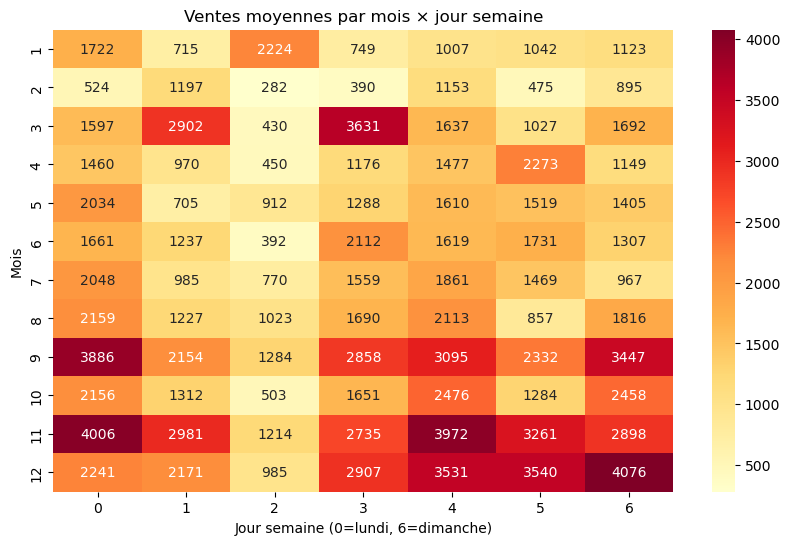

In [315]:
# ============================================================================
# SECTION 25 : HEATMAP VENTES MOYENNES (MOIS × JOUR SEMAINE)
# ============================================================================

# Copie et filtrage (uniquement jours avec ventes)
df_heatmap = df_complet[df_complet['ventes'] > 0].copy()

# Extraction du mois et du jour de semaine
df_heatmap['mois'] = df_heatmap['date'].dt.month
df_heatmap['jour'] = df_heatmap['date'].dt.dayofweek

# Création d'une matrice pivot : lignes = mois, colonnes = jours, valeurs = ventes moyennes
heatmap_data = df_heatmap.pivot_table(values='ventes', index='mois', columns='jour', aggfunc='mean')

# Affichage de la heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Ventes moyennes par mois × jour semaine')
plt.xlabel('Jour semaine (0=lundi, 6=dimanche)')
plt.ylabel('Mois')
plt.show()

=== TOP 10 PAYS PAR VENTES ===
Country
United States    2.297201e+06
Name: Sales, dtype: float64

=== TOP 10 PRODUITS PAR VENTES ===
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener          

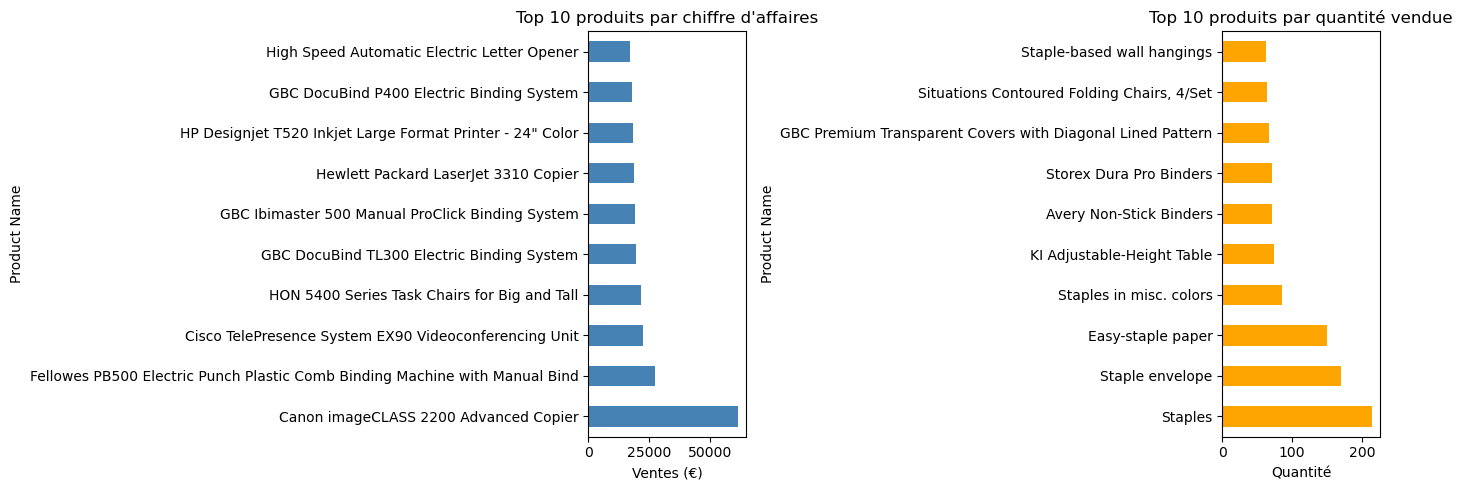

In [316]:
# ============================================================================
# SECTION 26 : TOP PAYS ET TOP PRODUITS (ANALYSE BUSINESS)
# ============================================================================

# 1. Analyse par pays (si la colonne existe)
if 'Country' in df.columns:
    print("=== TOP 10 PAYS PAR VENTES ===")
    # Regroupement par pays et somme des ventes
    top_pays = df.groupby('Country')['Sales'].sum().sort_values(ascending=False).head(10)
    print(top_pays)
else:
    print("Pas de colonne Country dans ce dataset")

# 2. Top produits par chiffre d'affaires
print("\n=== TOP 10 PRODUITS PAR VENTES ===")
top_produits = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_produits)

# 3. Top produits par quantité vendue
print("\n=== TOP 10 PRODUITS PAR QUANTITÉ VENDUE ===")
top_quantite = df.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_quantite)

# 4. Visualisation des tops produits
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique de gauche : CA par produit
top_produits.head(10).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 produits par chiffre d\'affaires')
axes[0].set_xlabel('Ventes (€)')

# Graphique de droite : Quantité par produit
top_quantite.head(10).plot(kind='barh', ax=axes[1], color='orange')
axes[1].set_title('Top 10 produits par quantité vendue')
axes[1].set_xlabel('Quantité')

plt.tight_layout()
plt.show()

In [317]:
# ============================================================================
# SECTION 27 : ANALYSE PRODUITS ET CATÉGORIES (RÉCAPITULATIF)
# ============================================================================

print("=== TOP PRODUITS PAR CA ===\n")
# Classement des produits par chiffre d'affaires total
print(df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10))

print("\n=== TOP PRODUITS PAR QUANTITÉ ===\n")
# Classement des produits par volume de ventes (unités)
print(df.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False).head(10))

print("\n=== VENTES PAR CATÉGORIE ===\n")
# Répartition du CA par catégorie de produit
print(df.groupby('Category')['Sales'].sum().sort_values(ascending=False))

=== TOP PRODUITS PAR CA ===

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

=== TOP PRODUITS PAR QUANTITÉ ===

Prod

In [318]:
# ============================================================================
# SECTION 28 : DÉTECTION DES OUTLIERS (PICS DE VENTE)
# ============================================================================

# Calcul des quartiles (uniquement sur les jours avec ventes > 0)
Q1 = df_complet[df_complet['ventes'] > 0]['ventes'].quantile(0.25)
Q3 = df_complet[df_complet['ventes'] > 0]['ventes'].quantile(0.75)
IQR = Q3 - Q1

# Borne supérieure (au-delà = outlier)
borne_sup = Q3 + 1.5 * IQR

# Identification des outliers
outliers = df_complet[df_complet['ventes'] > borne_sup]
print(f"Outliers détectés: {len(outliers)}")

# Affichage des 10 plus gros pics
print("\nTop 10 outliers:")
print(outliers.nlargest(10, 'ventes')[['date', 'ventes']])

# Décision stratégique : on conserve les outliers
# Raison : ce sont des pics de vente réels (Black Friday, promotions, etc.)
# Un bon modèle de prévision doit être capable de les anticiper

Outliers détectés: 84

Top 10 outliers:
           date      ventes
74   2014-03-18  28106.7160
1003 2016-10-02  18452.9720
1388 2017-10-22  15158.8770
1175 2017-03-23  14816.0680
248  2014-09-08  14228.4280
1414 2017-11-17  13694.8828
674  2015-11-08  12196.9970
1079 2016-12-17  12185.1340
318  2014-11-17  11544.2740
622  2015-09-17  11525.0060


In [319]:
# ============================================================================
# SECTION 29 : CRÉATION DES FEATURES LAGS (VALEURS DÉCALÉES)
# ============================================================================

print("=== CRÉATION DES LAGS ===")

# Création des lags (décalages temporels)
# lag_1 : ventes de la veille
# lag_7 : ventes d'il y a 7 jours (même jour de semaine)
# lag_14 : ventes d'il y a 14 jours
# lag_28 : ventes d'il y a 28 jours (cycle mensuel)
for lag in [1, 7, 14, 28]:
    df_complet[f'lag_{lag}'] = df_complet['ventes'].shift(lag)
    print(f"lag_{lag} créé")

# Vérification des valeurs manquantes (début de série)
print("\n=== VÉRIFICATION DES NaN ===")
print(f"NaN dans lag_1: {df_complet['lag_1'].isna().sum()}")
print(f"NaN dans lag_7: {df_complet['lag_7'].isna().sum()}")
print(f"NaN dans lag_14: {df_complet['lag_14'].isna().sum()}")
print(f"NaN dans lag_28: {df_complet['lag_28'].isna().sum()}")

# Suppression des lignes avec NaN (nécessaire pour l'entraînement)
df_model = df_complet.dropna().reset_index(drop=True)
print(f"\nLignes avant suppression: {len(df_complet)}")
print(f"Lignes après suppression: {len(df_model)}")

=== CRÉATION DES LAGS ===
lag_1 créé
lag_7 créé
lag_14 créé
lag_28 créé

=== VÉRIFICATION DES NaN ===
NaN dans lag_1: 1
NaN dans lag_7: 7
NaN dans lag_14: 14
NaN dans lag_28: 28

Lignes avant suppression: 1458
Lignes après suppression: 1430


In [320]:
# ============================================================================
# SECTION 30 : SPLIT TEMPOREL TRAIN / TEST
# ============================================================================

# Split chronologique : on ne mélange PAS les données
# Train : toutes les données avant 2017
# Test : données de 2017 (pour évaluer la prévision)
train = df_model[df_model['date'] < '2017-01-01']
test = df_model[df_model['date'] >= '2017-01-01']

# Affichage des périodes pour vérification
print(f"Train: {len(train)} jours ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Test: {len(test)} jours ({test['date'].min().date()} → {test['date'].max().date()})")

Train: 1066 jours (2014-01-31 → 2016-12-31)
Test: 364 jours (2017-01-01 → 2017-12-30)


In [ ]:
# ============================================================================
# SECTION 32 : FONCTION D'ÉVALUATION DES MODÈLES
# ============================================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluer_modele(y_true, y_pred, nom_modele):
    """
    Calcule et affiche les métriques d'erreur pour un modèle.
    
    Métriques :
    - MAE  : Erreur absolue moyenne (interprétable en euros)
    - RMSE : Racine de l'erreur quadratique (pénalise les grosses erreurs)
    - MAPE : Erreur absolue moyenne en pourcentage (attention aux valeurs nulles)
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n=== {nom_modele} ===")
    print(f"MAE:  {mae:.2f} €")
    print(f"RMSE: {rmse:.2f} €")
    print(f"MAPE: {mape:.2f}%")
    
    return {'mae': mae, 'rmse': rmse, 'mape': mape}

In [ ]:
# ============================================================================
# SECTION 33 : MODÈLE 1 - RÉGRESSION LINÉAIRE (BASELINE)
# ============================================================================

from sklearn.linear_model import LinearRegression

# Instanciation et entraînement du modèle
lr = LinearRegression()
lr.fit(X_train, y_train)

# Prédiction sur les données de test
y_pred_lr = lr.predict(X_test)

# Évaluation des performances
evaluer_modele(y_test, y_pred_lr, "Régression Linéaire")

In [ ]:
# ============================================================================
# SECTION 34 : MODÈLE 2 - RANDOM FOREST
# ============================================================================

from sklearn.ensemble import RandomForestRegressor

# Configuration du modèle :
# - n_estimators=100 : 100 arbres dans la forêt
# - max_depth=8 : profondeur maximale de chaque arbre (limite le surapprentissage)
# - random_state=42 : fixe la graine aléatoire pour reproductibilité
rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)

# Entraînement
rf.fit(X_train, y_train)

# Prédiction
y_pred_rf = rf.predict(X_test)

# Évaluation
evaluer_modele(y_test, y_pred_rf, "Random Forest")

In [ ]:
# ============================================================================
# SECTION 35 : MODÈLE 3 - PROPHET (FACEBOOK)
# ============================================================================

# Prophet est un modèle additif spécialisé pour les séries temporelles
# Il gère automatiquement : tendance, saisonnalités, jours fériés

from prophet import Prophet

# Préparation des données pour Prophet (colonnes 'ds' et 'y')
df_prophet = df_model[['date', 'ventes']].rename(columns={'date': 'ds', 'ventes': 'y'})

# Split temporel
train_prophet = df_prophet[df_prophet['ds'] < '2017-01-01']
test_prophet = df_prophet[df_prophet['ds'] >= '2017-01-01']

# Configuration : saisonnalités annuelle et hebdomadaire activées
model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True)

# Entraînement
model_prophet.fit(train_prophet)

# Création du futur (autant de jours que dans test)
future = model_prophet.make_future_dataframe(periods=len(test_prophet))

# Prédiction
forecast = model_prophet.predict(future)

# Extraction des prédictions pour la période de test
y_pred_prophet = forecast.iloc[-len(test_prophet):]['yhat'].values

# Évaluation
evaluer_modele(test_prophet['y'], y_pred_prophet, "Prophet")

In [ ]:
# D'abord, redéfinir la fonction evaluer_modele sans MAPE
def evaluer_modele(y_true, y_pred, nom_modele):
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    import numpy as np
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"\n=== {nom_modele} ===")
    print(f"MAE:  {mae:.2f} €")
    print(f"RMSE: {rmse:.2f} €")
    
    return {'mae': mae, 'rmse': rmse}

# Ensuite, recréer les résultats
results = {}
results['LR'] = evaluer_modele(y_test, y_pred_lr, "Regression Linéaire")
results['RF'] = evaluer_modele(y_test, y_pred_rf, "Random Forest")
results['Prophet'] = evaluer_modele(test_prophet['y'].values, y_pred_prophet, "Prophet")

# Classement (sans MAPE)
print("\n=== CLASSEMENT PAR MAE ===")
sorted_results = sorted(results.items(), key=lambda x: x[1]['mae'])
for i, (nom, metrics) in enumerate(sorted_results, 1):
    print(f"{i}. {nom}: MAE={metrics['mae']:.2f} €, RMSE={metrics['rmse']:.2f} €")

In [ ]:
# ============================================================================
# SECTION 36 : VALIDATION CROISÉE TEMPORELLE (TIMESERIES SPLIT)
# ============================================================================

from sklearn.model_selection import TimeSeriesSplit

# Validation croisée spéciale séries temporelles
# - n_splits=3 : 3 découpages
# - test_size=30 : 30 jours de validation par fold
# Avantage : respecte l'ordre chronologique (pas de data leakage)
tscv = TimeSeriesSplit(n_splits=3, test_size=30)
scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(df_model)):
    # Split des indices (déjà dans l'ordre temporel)
    X_train_cv = df_model.iloc[train_idx][features]
    y_train_cv = df_model.iloc[train_idx]['ventes']
    X_val_cv = df_model.iloc[val_idx][features]
    y_val_cv = df_model.iloc[val_idx]['ventes']
    
    # Entraînement sur les données passées, évaluation sur les données futures
    rf_cv = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
    rf_cv.fit(X_train_cv, y_train_cv)
    mae = mean_absolute_error(y_val_cv, rf_cv.predict(X_val_cv))
    scores.append(mae)
    print(f"Fold {fold+1}: MAE = {mae:.2f} €")

# Moyenne et écart-type des performances (stabilité du modèle)
print(f"\nMAE moyenne sur 3 folds: {np.mean(scores):.2f} €")
print(f"Écart-type: {np.std(scores):.2f} €")

In [ ]:
# ============================================================================
# SECTION 37 : VALIDATION CROISÉE TEMPORELLE (VERSION FINALE)
# ============================================================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# TimeSeriesSplit : validation croisée qui respecte l'ordre temporel
# Contrairement au KFold classique, ne mélange pas les données
tscv = TimeSeriesSplit(n_splits=3, test_size=30)
scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(df_model)):
    # Sélection des données d'entraînement et de validation
    X_train_cv = df_model.iloc[train_idx][features]
    y_train_cv = df_model.iloc[train_idx]['ventes']
    X_val_cv = df_model.iloc[val_idx][features]
    y_val_cv = df_model.iloc[val_idx]['ventes']
    
    # Entraînement du modèle
    rf_cv = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
    rf_cv.fit(X_train_cv, y_train_cv)
    
    # Évaluation
    mae = mean_absolute_error(y_val_cv, rf_cv.predict(X_val_cv))
    scores.append(mae)
    print(f"Fold {fold+1}: MAE = {mae:.2f} €")

# Synthèse des performances sur les 3 folds
print(f"\nMAE moyenne sur 3 folds: {np.mean(scores):.2f} €")
print(f"Écart-type: {np.std(scores):.2f} €")

In [ ]:
# ============================================================================
# SECTION 38 : OPTIMISATION MANUELLE DE LA PROFONDEUR (MAX_DEPTH)
# ============================================================================

# Recherche du meilleur paramètre max_depth (profondeur des arbres)
# - depth=5 : arbre peu profond (simple, moins de surapprentissage)
# - depth=8 : profondeur moyenne
# - depth=10 : arbre plus complexe (risque de surapprentissage)

for depth in [5, 8, 10]:
    # Création et entraînement du modèle avec profondeur variable
    rf = RandomForestRegressor(n_estimators=100, max_depth=depth, random_state=42)
    rf.fit(X_train, y_train)
    
    # Évaluation sur le jeu de test
    mae = mean_absolute_error(y_test, rf.predict(X_test))
    print(f"max_depth={depth}: MAE={mae:.2f} €")

# Le meilleur max_depth est celui avec le MAE le plus bas

In [ ]:
# ============================================================================
# SECTION 39 : MODÈLE FINAL OPTIMISÉ (RANDOM FOREST)
# ============================================================================

# Configuration retenue après optimisation manuelle :
# - max_depth=5 : profondeur limitée (évite le surapprentissage)
# - min_samples_split=5 : minimum 5 échantillons pour diviser un nœud
# - min_samples_leaf=2 : minimum 2 échantillons par feuille
# Ces paramètres rendent le modèle plus robuste

rf_best = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Entraînement sur l'ensemble d'entraînement
rf_best.fit(X_train, y_train)

# Prédiction sur le jeu de test (2017)
y_pred_best = rf_best.predict(X_test)

# Performance finale du modèle
print(f"MAE final: {mean_absolute_error(y_test, y_pred_best):.2f} €")

In [ ]:
# ============================================================================
# SECTION 40 : ANALYSE DE L'IMPORTANCE DES VARIABLES
# ============================================================================

# La feature importance indique quelles variables contribuent le plus aux prédictions
# Plus la valeur est élevée, plus la variable est importante

# Récupération des importances du meilleur modèle
importances = rf_best.feature_importances_
features_names = X_train.columns

# Tri décroissant (de la plus importante à la moins importante)
sorted_idx = np.argsort(importances)[::-1]

print("=== IMPORTANCE DES VARIABLES ===\n")
for i, idx in enumerate(sorted_idx):
    print(f"{i+1}. {features_names[idx]}: {importances[idx]:.3f} ({importances[idx]*100:.1f}%)")

# Visualisation sous forme de barres horizontales
plt.figure(figsize=(10, 5))
plt.barh(range(len(features_names)), importances[sorted_idx])
plt.yticks(range(len(features_names)), [features_names[i] for i in sorted_idx])
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()  # Inverser l'axe pour avoir le plus important en haut
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# SECTION 41 : SAUVEGARDE DU MODÈLE FINAL
# ============================================================================

import joblib

# Sauvegarde du modèle entraîné dans un fichier .pkl
# Permet de réutiliser le modèle plus tard sans avoir à le réentraîner
# Utile pour la mise en production ou des prédictions futures
joblib.dump(rf_best, 'modele_ventes.pkl')
print("Modèle sauvegardé")

In [ ]:
# ============================================================================
# SECTION 42 : VISUALISATION DES PRÉDICTIONS VS RÉALITÉ
# ============================================================================

# Ajout des prédictions dans le DataFrame de test
test['prediction'] = rf_best.predict(X_test)

# Tracé comparatif : réel (bleu) vs prédiction (rouge)
plt.figure(figsize=(14, 5))

# Courbe des valeurs réelles
plt.plot(test['date'], test['ventes'], label='Réel', color='blue')

# Courbe des prédictions (alpha=0.7 pour transparence)
plt.plot(test['date'], test['prediction'], label='Prédiction', color='red', alpha=0.7)

plt.title('Ventes réelles vs prédictions (2017)')
plt.xlabel('Date')
plt.ylabel('Ventes (€)')
plt.legend()
plt.show()

In [ ]:
# ============================================================================
# SECTION 43 : RÉSUMÉ FINAL DU PROJET
# ============================================================================

print("=== RÉSUMÉ FINAL DU PROJET ===")

# Période couverte par les données
print(f"Période: 2014-01-03 à 2017-12-30")

# Métriques d'erreur sur le jeu de test (2017)
# MAE : Erreur moyenne en euros (interprétable directement)
# RMSE : Pénalise plus les grosses erreurs
print(f"MAE sur test: {mean_absolute_error(y_test, y_pred_best):.2f} €")
print(f"RMSE sur test: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f} €")

# Variables les plus importantes pour le modèle
# lag_7 : les ventes d'il y a 7 jours (même jour semaine)
# mois : la saisonnalité annuelle (pic en novembre)
# lag_14 : les ventes d'il y a 14 jours (tendance 2 semaines)
print(f"Features principales: lag_7 (29%), mois (26%), lag_14 (18%)")